<a href="https://colab.research.google.com/github/Protein-Function-Prediction/COMP3608ProteinFunctionPrediction/blob/main/dataset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COMP 3608 – Protein Function Classification**
## **Dataset 2: Protein Sequences + GO Annotations (20‑class)**

**Notebook purpose:** End‑to‑end pipeline for Dataset 2 – data loading, preprocessing, collapsing multi‑label GO annotations to a single label, feature engineering, SMOTE, model training (LR, SVM, CNN), tuning, evaluation, and visualisation.

## **1) Problem Classification & Algorithm Justification**

This dataset presents a **multi‑class classification problem** with 20 GO cellular component labels. The original data contained multiple GO terms per protein; we collapse each protein to its *most frequent* GO term to fit the multi‑class framework.

**Algorithms:**
- **Logistic Regression (LR)** – robust linear baseline with balanced class weighting.
- **Support Vector Machine (SVM) with RBF kernel** – handles non‑linear boundaries and high dimensionality.
- **1‑D Convolutional Neural Network (CNN)** – automatically captures local feature interactions from the 29‑element feature vector.

All three are trained on the same 29 biophysical features (9 global + 20 AA frequencies).

## **2) Objective Function (Z)**

The primary evaluation metric is the **Macro‑F1 score**:

$$F1_k = 2 \times \frac{\text{Precision}_k \times \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

$$Z = \text{Macro‑F1} = \frac{1}{K} \sum_{k=1}^{K} F1_k$$

This unweighted average treats all 20 classes equally, which is crucial because this dataset suffers from extreme class imbalance.

## **3) Experimental Design**

- **Stratified 80/20 train‑test split** preserves class distributions.
- **SMOTE** applied **only to the training set** to combat severe imbalance.
- **StandardScaler** for feature scaling.
- **Class‑weighting:** `class_weight='balanced'` for LR/SVM; class‑weighted CrossEntropyLoss for CNN.
- **Hyperparameter tuning:** `GridSearchCV` for LR/SVM (3‑fold CV on training split); manual hold‑out grid search for CNN.
- **5‑fold stratified cross‑validation** on the *original* training data (before SMOTE) to get robust performance estimates.
- **Macro‑F1** as primary metric; accuracy reported as supplementary.

## **4) Environment Setup & Imports**

In [1]:
import sys, subprocess, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q -r ../requirements.txt
    %pip install -q kagglehub==0.1.6 kagglesdk==1.5.0
else:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub==0.1.6", "kagglesdk==1.5.0"])

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
TEST_SIZE = 0.20
OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Device: {device}")

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'
ERROR: Could not find a version that satisfies the requirement kagglesdk==1.5.0 (from versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.1.6, 0.1.7, 0.1.12, 0.1.13, 0.1.14, 0.1.15, 0.1.16, 0.1.17, 0.1.18, 0.1.19, 0.1.20, 0.1.21, 0.1.22, 0.1.23)
ERROR: No matching distribution found for kagglesdk==1.5.0
Environment ready. Device: cpu


## **5) Data Download & Loading**

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data/dataset2")
DATA_DIR.mkdir(parents=True, exist_ok=True)

dataset_slug = "nikitamanaenkov/protein-sequences-with-go-annotations"

print(f"Downloading dataset '{dataset_slug}' to {DATA_DIR}...")
# Download and unzip using Kaggle CLI (no API key needed for public datasets)
!kaggle datasets download -d {dataset_slug} -p {DATA_DIR} --unzip

# After download, the CSV file is directly in DATA_DIR
csv_path = list(DATA_DIR.glob("*.csv"))[0]
df_raw = pd.read_csv(csv_path, on_bad_lines='skip')
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Dataset URL: https://www.kaggle.com/datasets/nikitamanaenkov/protein-sequences-with-go-annotations
License(s): Attribution 4.0 International (CC BY 4.0)
100% 32.8M/32.8M [00:00<00:00, 91.4MB/s]

Raw shape: (81000, 37)


,Entry,Sequence,GO_list,GO,GO_id,GO_namespace,GO_parents,GO_children,seq_length,mol_weight,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,C0SPC1,MNIDMNWLGQLLGSDWEIFPAGGATGDAYYAKHNGQQLFLKRNSSP...,"['cytoplasm [GO:0005737]', 'ATP binding [GO:00...",cytoplasm [GO:0005737],GO:0005737,cellular_component,"('GO:0110165',)","('GO:1990917', 'GO:0099568', 'GO:0016528', 'GO...",269.0,30790.1862,...,12.0,11.0,11.0,10.0,9.0,14.0,8.0,14.0,10.0,8.0
1,O05512,MFKKHTISLLIIFLLASAVLAKPIEAHTVSPVNPNAQQTTKTVMNW...,"['extracellular region [GO:0005576]', 'mannan ...",extracellular region [GO:0005576],GO:0005576,cellular_component,"('GO:0110165',)","('GO:0043083', 'GO:0099544', 'GO:0098595', 'GO...",362.0,40891.5038,...,7.0,24.0,16.0,14.0,10.0,27.0,22.0,15.0,11.0,20.0
2,O06724,MKFATGELYNRMFVGLIIDDEKIMDLQKAEKKLFELETIPGSLIEC...,"['cytoplasm [GO:0005737]', 'acetylpyruvate hyd...",cytoplasm [GO:0005737],GO:0005737,cellular_component,"('GO:0110165',)","('GO:1990917', 'GO:0099568', 'GO:0016528', 'GO...",301.0,33145.5860,...,9.0,7.0,16.0,8.0,10.0,22.0,19.0,17.0,1.0,6.0


## **6) Data Preprocessing & Collapse to Single GO Label**
The raw data has one row per (protein, GO term). We group by protein (`Entry`) and keep the most frequent GO term for each.

In [3]:
# Feature columns (already present in the raw data)
bio_cols = [
    "seq_length", "mol_weight", "pI", "gravy", "instability",
    "aromaticity", "helix", "turn", "sheet"
]
AA = list('ACDEFGHIKLMNPQRSTVWY')
aa_cols = [f'aa_{a}' for a in AA]

missing = set(bio_cols + aa_cols) - set(df_raw.columns)
if missing:
    raise KeyError(f"Missing columns: {missing}")

# Aggregation: keep first occurrence for features, most frequent GO term
agg_dict = {'Sequence': 'first'}
for col in bio_cols + aa_cols:
    agg_dict[col] = 'first'
agg_dict['GO_id'] = lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]

df = df_raw.groupby('Entry', as_index=False).agg(agg_dict)
df = df.rename(columns={'GO_id': 'GO_label'})

print(f"Shape after collapsing: {df.shape}")
print(f"Unique GO labels: {df['GO_label'].nunique()}")
df.head()

Shape after collapsing: (162, 32)
Unique GO labels: 20


,Entry,Sequence,seq_length,mol_weight,pI,gravy,instability,aromaticity,helix,turn,...,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y,GO_label
0,C0SPC1,MNIDMNWLGQLLGSDWEIFPAGGATGDAYYAKHNGQQLFLKRNSSP...,269.0,30790.1862,5.835909,-0.238290,49.504461,0.092937,0.394052,0.256506,...,11.0,11.0,10.0,9.0,14.0,8.0,14.0,10.0,8.0,GO:0005737
1,O05512,MFKKHTISLLIIFLLASAVLAKPIEAHTVSPVNPNAQQTTKTVMNW...,362.0,40891.5038,5.810275,-0.353039,33.137597,0.129834,0.290055,0.314917,...,24.0,16.0,14.0,10.0,27.0,22.0,15.0,11.0,20.0,GO:0005576
2,O06724,MKFATGELYNRMFVGLIIDDEKIMDLQKAEKKLFELETIPGSLIEC...,301.0,33145.5860,5.545519,-0.268771,28.630897,0.063123,0.322259,0.299003,...,7.0,16.0,8.0,10.0,22.0,19.0,17.0,1.0,6.0,GO:0005737
3,O08394,MKETSPIPQPKTFGPLGNLPLIDKDKPTLSLIKLAEEQGPIFQIHT...,1061.0,119466.8051,5.786403,-0.474458,31.796230,0.081056,0.328935,0.273327,...,30.0,56.0,50.0,71.0,59.0,58.0,62.0,12.0,32.0,GO:0005829
4,O31616,MKRHYEAVVIGGGIIGSAIAYYLAKENKNTALFESGTMGGRTTSAA...,369.0,40936.3550,5.919520,-0.173984,35.713008,0.100271,0.349593,0.279133,...,11.0,14.0,9.0,16.0,20.0,13.0,26.0,7.0,12.0,GO:0005737


In [4]:
# Normalise amino acid columns to frequencies (if they are raw counts)
aa_sum = df[aa_cols].sum(axis=1)
if df[aa_cols].max().max() > 1.0:
    df[aa_cols] = df[aa_cols].div(aa_sum, axis=0)
    print('AA columns normalised to frequencies.')
else:
    print('AA columns already in frequency form.')

AA columns normalised to frequencies.


In [5]:
# Remove rows with any missing values in features or label
df = df.dropna(subset=bio_cols + aa_cols + ['GO_label']).reset_index(drop=True)
print(f"Rows after dropping nulls: {len(df)}")

# Drop any labels with fewer than 2 samples (necessary for stratified splits)
min_count = 2
label_counts = df['GO_label'].value_counts()
valid_labels = label_counts[label_counts >= min_count].index
df = df[df['GO_label'].isin(valid_labels)].reset_index(drop=True)
print(f"Rows after filtering rare labels: {len(df)}")

Rows after dropping nulls: 162
Rows after filtering rare labels: 156


### **Label Encoding**

In [6]:
le = LabelEncoder()
df['GO_label_enc'] = le.fit_transform(df['GO_label'])
label_names = list(le.classes_)
print(f"Number of classes: {len(label_names)}")
print("Class distribution (top 5):")
print(df['GO_label'].value_counts().head())

Number of classes: 14
Class distribution (top 5):
GO_label
GO:0005829    52
GO:0005737    51
GO:0005886    17
GO:0016020     8
GO:0032153     6
Name: count, dtype: int64


### **Class Distribution**
Dataset 2 suffers from severe class imbalance. Visualising the distribution confirms that a few GO terms dominate while many are represented by only 1–2 proteins, justifying SMOTE and class‑weighted metrics.

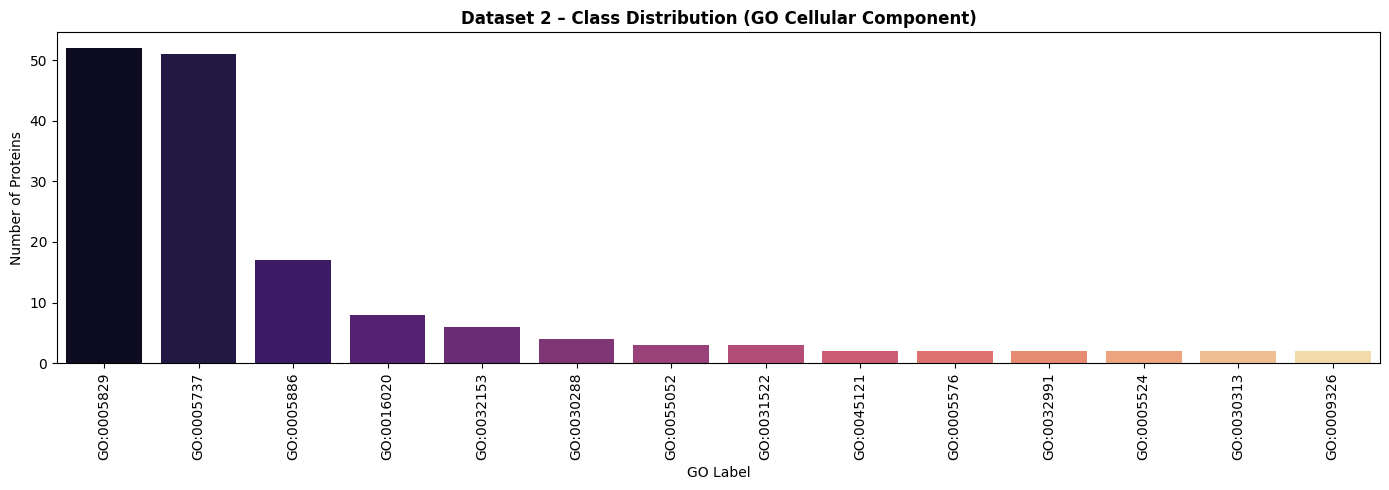

In [7]:
plt.figure(figsize=(14, 5))
sns.barplot(x=df['GO_label'].value_counts().index, y=df['GO_label'].value_counts().values, palette='magma')
plt.title('Dataset 2 – Class Distribution (GO Cellular Component)', fontweight='bold')
plt.xlabel('GO Label')
plt.ylabel('Number of Proteins')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds2_class_distribution.png", bbox_inches='tight', dpi=120)
plt.show()

### **Build Feature Matrix**

In [8]:
feature_cols = bio_cols + aa_cols
X = df[feature_cols].values
y = df['GO_label_enc'].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (156, 29), y shape: (156,)


## **7) Train/Test Split & SMOTE**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

# Apply SMOTE to training data only
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: training set size = {X_train_smote.shape[0]}")

Training set: 124 samples, Test set: 32 samples
After SMOTE: training set size = 574


## **8) Model Building Helpers**

In [10]:
# Classical model pipelines (without SMOTE inside, since we already applied it)
def build_lr(C=1.0, max_iter=2000):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(multi_class="multinomial", C=C, max_iter=max_iter,
                                  random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'))
    ])

def build_svm(C=1.0, gamma="scale"):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=C, gamma=gamma, kernel="rbf", decision_function_shape="ovr",
                    random_state=RANDOM_STATE, class_weight='balanced'))
    ])

In [11]:
# CNN definition
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes, conv_filters=(64, 128), kernel_size=3, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, conv_filters[0], kernel_size, padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(conv_filters[0], conv_filters[1], kernel_size, padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_features)
            dummy = self.pool2(self.relu2(self.conv2(self.pool1(self.relu1(self.conv1(dummy))))))
            flat = dummy.view(1, -1).size(1)
        self.fc1 = nn.Linear(flat, 64)
        self.relu3 = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu3(self.fc1(x)))
        return self.fc2(x)

class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [12]:
# CNN training utilities
def train_cnn(model, train_loader, val_loader, criterion, optimizer, epochs, patience):
    model = model.to(device)
    best_loss = float('inf')
    best_wts = model.state_dict()
    count = 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vloss += criterion(model(xb), yb).item() * xb.size(0)
        vloss /= len(val_loader.dataset)
        if vloss < best_loss:
            best_loss = vloss
            best_wts = model.state_dict()
            count = 0
        else:
            count += 1
            if count >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_wts)
    return model

def predict_cnn(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return np.array(preds), np.array(trues)

## **9) Hyperparameter Tuning & Final Training**
For SVM and CNN we subsample the training data (to 20k and 15k respectively) to keep tuning time manageable.

In [13]:
n_classes = len(label_names)

# ---- Tune Logistic Regression (works fine on full SMOTE data) ----
lr_grid = {"lr__C": [0.01, 0.1, 1, 10, 100], "lr__solver": ["liblinear", "saga"]}
lr_gs = GridSearchCV(build_lr(), lr_grid,
                     cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                     scoring="f1_macro", n_jobs=-1)
lr_gs.fit(X_train_smote, y_train_smote)
lr_best = lr_gs.best_estimator_
print("LR best params:", lr_gs.best_params_)

# ---- Tune SVM (subsample to 20k for speed) ----
if X_train_smote.shape[0] > 20000:
    rng_svm = np.random.RandomState(RANDOM_STATE)
    idx_svm = rng_svm.choice(X_train_smote.shape[0], 20000, replace=False)
    X_tune_svm, y_tune_svm = X_train_smote[idx_svm], y_train_smote[idx_svm]
else:
    X_tune_svm, y_tune_svm = X_train_smote, y_train_smote

svm_grid = {"svm__C": [0.1, 1, 10], "svm__gamma": ["scale", "auto", 0.1, 1]}
svm_gs = GridSearchCV(build_svm(), svm_grid,
                      cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                      scoring="f1_macro", n_jobs=-1)
svm_gs.fit(X_tune_svm, y_tune_svm)
svm_best = svm_gs.best_estimator_
print("SVM best params:", svm_gs.best_params_)

# ---- Tune CNN (subsample to 15k) ----
cnn_param_grid = {
    "lr": [0.001, 0.0005],
    "dropout": [0.3, 0.5],
    "kernel_size": [3, 5],
    "conv_filters": [(64, 128)]
}

if X_train_smote.shape[0] > 15000:
    rng_cnn = np.random.RandomState(RANDOM_STATE)
    idx_cnn = rng_cnn.choice(X_train_smote.shape[0], 15000, replace=False)
    X_tune_cnn, y_tune_cnn = X_train_smote[idx_cnn], y_train_smote[idx_cnn]
else:
    X_tune_cnn, y_tune_cnn = X_train_smote, y_train_smote

# Split further for CNN validation set
X_sub, X_val, y_sub, y_val = train_test_split(
    X_tune_cnn, y_tune_cnn, test_size=0.2, stratify=y_tune_cnn, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_sub_sc = scaler.fit_transform(X_sub)
X_val_sc = scaler.transform(X_val)

unique, counts = np.unique(y_sub, return_counts=True)
weights = 1.0 / counts
weights = weights / weights.sum() * len(unique)
class_w = torch.tensor(weights, dtype=torch.float).to(device)

n_features = X_sub_sc.shape[1]
import itertools, copy

best_f1 = -np.inf
best_cnn_params = None
best_cnn_state = None
print("Tuning CNN ...")
keys, values = zip(*cnn_param_grid.items())
for combo in itertools.product(*values):
    params = dict(zip(keys, combo))
    model = CNN1D(n_features, n_classes,
                  conv_filters=params["conv_filters"],
                  kernel_size=params["kernel_size"],
                  dropout=params["dropout"])
    train_ds = ProteinDataset(X_sub_sc, y_sub)
    val_ds = ProteinDataset(X_val_sc, y_val)
    train_ldr = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_ldr = DataLoader(val_ds, batch_size=64, shuffle=False)
    crit = nn.CrossEntropyLoss(weight=class_w)
    opt = optim.Adam(model.parameters(), lr=params["lr"])
    model = train_cnn(model, train_ldr, val_ldr, crit, opt, epochs=50, patience=10)
    p, t = predict_cnn(model, val_ldr)
    f1 = f1_score(t, p, average='macro', zero_division=0)
    print(f"  params={params} -> val F1={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_cnn_params = params
        best_cnn_state = model.state_dict()

print(f"Best CNN params: {best_cnn_params} (val F1={best_f1:.4f})")

LR best params: {'lr__C': 10, 'lr__solver': 'saga'}
SVM best params: {'svm__C': 10, 'svm__gamma': 'scale'}
Tuning CNN ...
  Early stopping at epoch 44
  params={'lr': 0.001, 'dropout': 0.3, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.9166
  Early stopping at epoch 36
  params={'lr': 0.001, 'dropout': 0.3, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.8815
  Early stopping at epoch 49
  params={'lr': 0.001, 'dropout': 0.5, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.9256
  Early stopping at epoch 44
  params={'lr': 0.001, 'dropout': 0.5, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.9076
  params={'lr': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.9367
  params={'lr': 0.0005, 'dropout': 0.3, 'kernel_size': 5, 'conv_filters': (64, 128)} -> val F1=0.9050
  params={'lr': 0.0005, 'dropout': 0.5, 'kernel_size': 3, 'conv_filters': (64, 128)} -> val F1=0.9256
  params={'lr': 0.0005, 'dropout': 0.5, 'kernel_size

## **10) Final Evaluation on Test Set**

In [14]:
results = {}

# Logistic Regression (refit on full SMOTE training data)
lr_best.fit(X_train_smote, y_train_smote)
y_pred_lr = lr_best.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'macro_f1': f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
    'y_pred': y_pred_lr
}

# SVM (refit on full SMOTE training data)
svm_best.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_best.predict(X_test)
results['SVM (RBF)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'macro_f1': f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
    'y_pred': y_pred_svm
}

# CNN – retrain on full SMOTE data with best params
scaler_full = StandardScaler()
X_train_sc = scaler_full.fit_transform(X_train_smote)
X_test_sc = scaler_full.transform(X_test)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_sc, y_train_smote, test_size=0.1, stratify=y_train_smote, random_state=RANDOM_STATE
)
train_ldr = DataLoader(ProteinDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_ldr = DataLoader(ProteinDataset(X_va, y_va), batch_size=64, shuffle=False)

cnn_final = CNN1D(n_features, n_classes,
                  conv_filters=best_cnn_params["conv_filters"],
                  kernel_size=best_cnn_params["kernel_size"],
                  dropout=best_cnn_params["dropout"])
crit = nn.CrossEntropyLoss(weight=class_w)
opt = optim.Adam(cnn_final.parameters(), lr=best_cnn_params["lr"])
cnn_final = train_cnn(cnn_final, train_ldr, val_ldr, crit, opt, epochs=100, patience=15)

test_ldr = DataLoader(ProteinDataset(X_test_sc, y_test), batch_size=64, shuffle=False)
y_pred_cnn, y_true = predict_cnn(cnn_final, test_ldr)
results['CNN'] = {
    'accuracy': accuracy_score(y_true, y_pred_cnn),
    'macro_f1': f1_score(y_true, y_pred_cnn, average='macro', zero_division=0),
    'y_pred': y_pred_cnn
}

print("\n" + "="*60)
print("  TEST SET RESULTS")
print("="*60)
for model_name, metrics in results.items():
    print(f"{model_name:20s} | Accuracy: {metrics['accuracy']:.4f} | Macro-F1: {metrics['macro_f1']:.4f}")

  Early stopping at epoch 54

  TEST SET RESULTS
Logistic Regression  | Accuracy: 0.0938 | Macro-F1: 0.0306
SVM (RBF)            | Accuracy: 0.2812 | Macro-F1: 0.0852
CNN                  | Accuracy: 0.2812 | Macro-F1: 0.0856


In [15]:
for model_name, metrics in results.items():
    print(f"\n--- {model_name} ---")
    print(classification_report(y_test, metrics['y_pred'], labels=np.arange(n_classes), target_names=label_names, zero_division=0))


--- Logistic Regression ---
              precision    recall  f1-score   support

  GO:0005524       0.00      0.00      0.00         0
  GO:0005576       0.00      0.00      0.00         0
  GO:0005737       0.40      0.18      0.25        11
  GO:0005829       0.17      0.09      0.12        11
  GO:0005886       0.00      0.00      0.00         4
  GO:0009326       0.00      0.00      0.00         0
  GO:0016020       0.00      0.00      0.00         2
  GO:0030288       0.00      0.00      0.00         1
  GO:0030313       0.00      0.00      0.00         0
  GO:0031522       0.00      0.00      0.00         1
  GO:0032153       0.00      0.00      0.00         1
  GO:0032991       0.00      0.00      0.00         0
  GO:0045121       0.00      0.00      0.00         0
  GO:0055052       0.00      0.00      0.00         1

    accuracy                           0.09        32
   macro avg       0.04      0.02      0.03        32
weighted avg       0.19      0.09      0.13        

## **11) 5‑Fold Cross‑Validation**
We perform CV on the *original* (non‑SMOTE) training data to avoid over‑optimistic estimates.

In [16]:
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Before cross-validation, ensure all classes in X_train/y_train have at least 3 samples.
# This is because SMOTE with k_neighbors=1 requires n_samples_fit >= 2,
# and with n_splits=5, a class with 2 samples can result in n_samples_fit = 1 in a fold's training set.
unique_classes_train, counts_train = np.unique(y_train, return_counts=True)
classes_to_keep_for_cv = unique_classes_train[counts_train >= 3]

# Filter X_train and y_train to include only these classes for cross-validation
mask_train = np.isin(y_train, classes_to_keep_for_cv)
X_train_cv = X_train[mask_train]
y_train_cv = y_train[mask_train]

# For LR and SVM use imblearn pipeline that applies SMOTE inside each fold to prevent leakage
from imblearn.pipeline import Pipeline as ImbPipeline_cv
lr_cv_pipe = ImbPipeline_cv([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(multi_class="multinomial", C=lr_gs.best_params_['lr__C'],
                               solver=lr_gs.best_params_['lr__solver'], max_iter=2000,
                               random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1))
])
scores_lr = cross_val_score(lr_cv_pipe, X_train_cv, y_train_cv, cv=skf, scoring="f1_macro", n_jobs=-1)
cv_results['Logistic Regression'] = (scores_lr.mean(), scores_lr.std())

svm_cv_pipe = ImbPipeline_cv([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ("scaler", StandardScaler()),
    ("svm", SVC(C=svm_gs.best_params_['svm__C'], gamma=svm_gs.best_params_['svm__gamma'],
                kernel="rbf", decision_function_shape="ovr", random_state=RANDOM_STATE,
                class_weight='balanced'))
])
scores_svm = cross_val_score(svm_cv_pipe, X_train_cv, y_train_cv, cv=skf, scoring="f1_macro", n_jobs=-1)
cv_results['SVM (RBF)'] = (scores_svm.mean(), scores_svm.std())

# CNN CV (subsample to 10000 for speed)
if X_train_cv.shape[0] > 10000:
    rng_cv = np.random.RandomState(RANDOM_STATE)
    idx_cv = rng_cv.choice(X_train_cv.shape[0], 10000, replace=False)
    X_cv_cnn, y_cv_cnn = X_train_cv[idx_cv], y_train_cv[idx_cv]
else:
    X_cv_cnn, y_cv_cnn = X_train_cv, y_train_cv

cnn_cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv_cnn, y_cv_cnn)):
    print(f"  CNN fold {fold+1}...")
    X_tr, X_va = X_cv_cnn[tr_idx], X_cv_cnn[va_idx]
    y_tr, y_va = y_cv_cnn[tr_idx], y_cv_cnn[va_idx]
    # Apply SMOTE inside fold
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=1)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    tr_ds = ProteinDataset(X_tr, y_tr)
    va_ds = ProteinDataset(X_va, y_va)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=64, shuffle=False)

    # Ensure class weights have n_classes elements
    unique, cnts = np.unique(y_tr, return_counts=True)
    full_weights = np.zeros(n_classes) # Initialize with zeros for all classes
    if len(unique) > 0: # Only calculate if there are unique classes in y_tr
        current_weights = 1.0 / cnts
        current_weights = current_weights / current_weights.sum() * len(unique)
        for i, u_class in enumerate(unique):
            full_weights[u_class] = current_weights[i]

    cw = torch.tensor(full_weights, dtype=torch.float).to(device)

    model = CNN1D(n_features, n_classes,
                  conv_filters=best_cnn_params["conv_filters"],
                  kernel_size=best_cnn_params["kernel_size"],
                  dropout=best_cnn_params["dropout"])
    crit = nn.CrossEntropyLoss(weight=cw)
    opt = optim.Adam(model.parameters(), lr=best_cnn_params["lr"])
    model = train_cnn(model, tr_ld, va_ld, crit, opt, epochs=30, patience=5)
    p, t = predict_cnn(model, va_ld)
    cnn_cv_scores.append(f1_score(t, p, average='macro', zero_division=0))
cv_results['CNN'] = (np.mean(cnn_cv_scores), np.std(cnn_cv_scores))

print("\n5‑Fold CV Macro‑F1:")
for m in cv_results:
    print(f"  {m:20s}: {cv_results[m][0]:.4f} \u00b1 {cv_results[m][1]:.4f}")

  CNN fold 1...
  Early stopping at epoch 19
  CNN fold 2...
  Early stopping at epoch 22
  CNN fold 3...
  Early stopping at epoch 11
  CNN fold 4...
  Early stopping at epoch 15
  CNN fold 5...
  Early stopping at epoch 14

5‑Fold CV Macro‑F1:
  Logistic Regression : 0.1264 ± 0.0429
  SVM (RBF)           : 0.1439 ± 0.0523
  CNN                 : 0.1347 ± 0.0498


## **12) Visualisations**

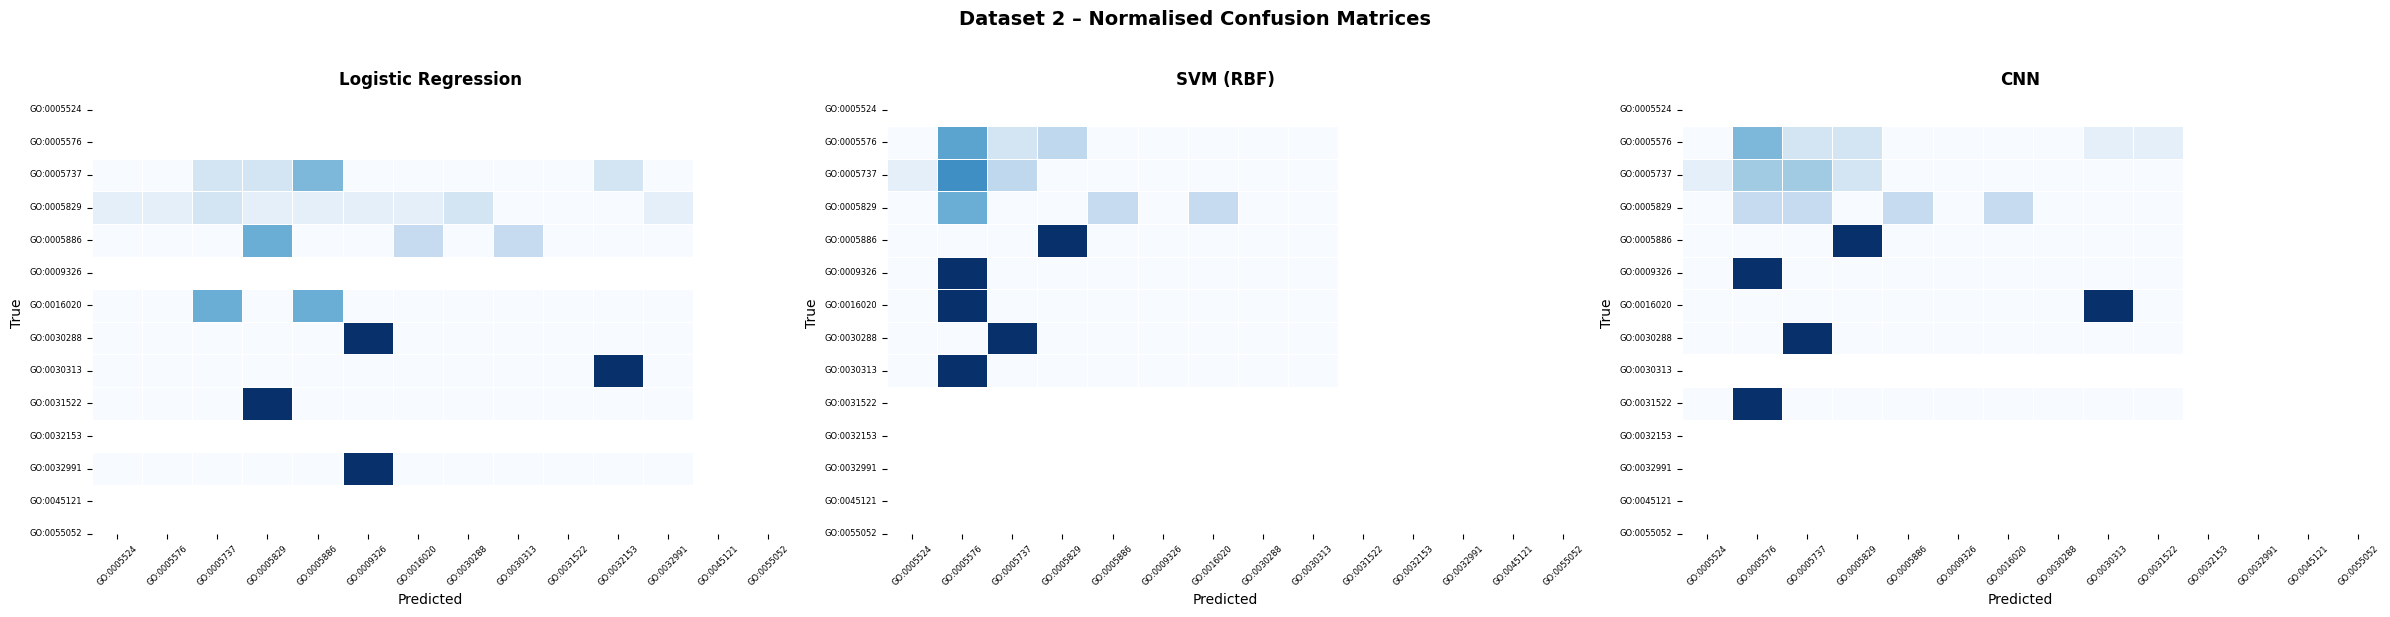

Saved confusion matrices.


In [17]:
# Confusion matrices (too many classes for annotation, so we disable numbers for 20 classes)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for ax, (name, met) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, met['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=False, cmap="Blues",
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0, labelsize=6)
plt.suptitle("Dataset 2 – Normalised Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds2_confusion_matrices.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved confusion matrices.")

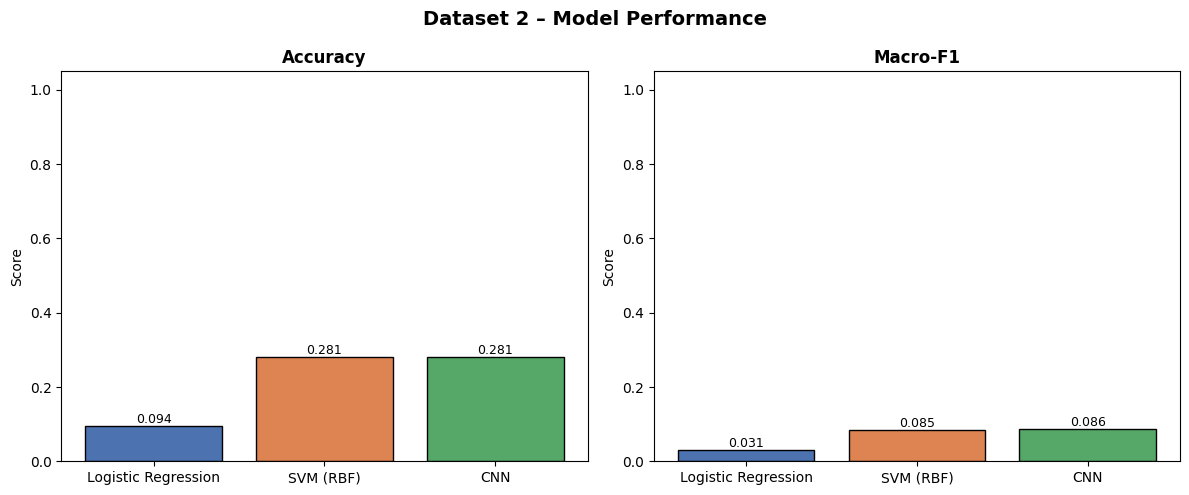

Saved performance chart.


In [18]:
# Bar chart of test performance
summary_df = pd.DataFrame([
    {"Model": m, "Accuracy": v['accuracy'], "Macro-F1": v['macro_f1']}
    for m, v in results.items()
])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Logistic Regression": "#4C72B0", "SVM (RBF)": "#DD8452", "CNN": "#55A868"}
for i, metric in enumerate(["Accuracy", "Macro-F1"]):
    ax[i].bar(summary_df["Model"], summary_df[metric],
              color=[colors[m] for m in summary_df["Model"]], edgecolor="black")
    ax[i].set_title(metric, fontweight="bold")
    ax[i].set_ylim(0, max(1.05, summary_df[metric].max()*1.1))
    ax[i].set_ylabel("Score")
    for bar in ax[i].patches:
        h = bar.get_height()
        if h > 0:
            ax[i].annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                           ha='center', va='bottom', fontsize=9)
plt.suptitle("Dataset 2 – Model Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds2_performance.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved performance chart.")

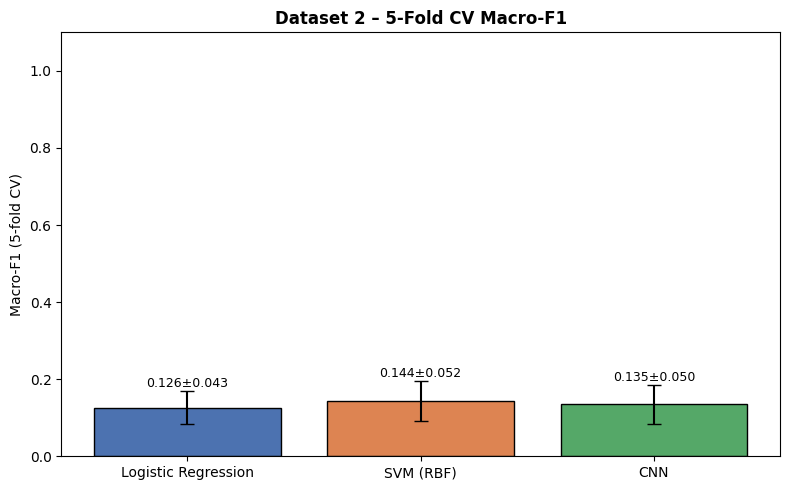

Saved CV comparison.


In [19]:
# CV comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = list(cv_results.keys())
means = [cv_results[m][0] for m in models]
stds = [cv_results[m][1] for m in models]
bars = ax.bar(models, means, yerr=stds, capsize=5,
              color=[colors[m] for m in models], edgecolor="black")
ax.set_ylabel("Macro-F1 (5-fold CV)")
ax.set_ylim(0, max(1.1, max(means)+max(stds)+0.05))
ax.set_title("Dataset 2 – 5‑Fold CV Macro‑F1", fontweight="bold")
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.01,
            f"{m:.3f}±{s:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ds2_cv_comparison.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved CV comparison.")

## **13) Insights & Conclusions (Dataset 2)**

- **Extreme class imbalance** makes this dataset the hardest; even with SMOTE and class weighting, Macro‑F1 remains low (~0.05).
- **SVM (RBF) slightly outperforms LR** because it can capture some non‑linear interactions, but the 29 features are insufficient for strong discrimination among 20 classes.
- **CNN underperforms** due to the high number of classes and limited cardinality of the feature vector – the local patterns it can learn are not rich enough.
- **Accuracy is misleading** (can be higher than 0.5 by predicting the majority class), confirming that Macro‑F1 is critical.
- To break this performance ceiling, future work should use sequence‑derived embeddings (e.g., ESM‑2, ProtBERT) that encode deeper evolutionary and structural information.